# Bài 2 — Mô hình hóa bài toán mê cung

Notebook này hoàn thiện bài tập theo ba mục tiêu:

1. Mô hình hóa mê cung thành một **bài toán tìm kiếm** với đủ năm thành phần.
2. Tính/ước lượng có kiểm chứng các đại lượng $n, d, m, b$ cho cả 8 mê cung.
3. Trực quan hóa mê cung và một đường đi ngắn nhất để có thể kiểm tra kết quả bằng mắt.

> Quy ước dữ liệu: `X` là tường, `S` là điểm bắt đầu, `G` là đích, dấu cách là ô có thể đi. Tọa độ dùng dạng `(hàng, cột)`, đánh số từ 0.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from IPython.display import display

MAZE_FILES = [
    'small_maze.txt', 'medium_maze.txt', 'large_maze.txt',
    'open_maze.txt', 'L_maze.txt', 'loops_maze.txt',
    'empty_maze.txt', 'empty_maze_2.txt',
]

# Chạy được khi mở notebook tại thư mục lab02 hoặc từ thư mục gốc repository.
candidates = [Path.cwd(), Path.cwd() / 'weekly assignments' / 'lab02 - Searching']
MAZE_DIR = next((p for p in candidates if (p / 'small_maze.txt').exists()), None)
if MAZE_DIR is None:
    raise FileNotFoundError('Không tìm thấy các file *_maze.txt.')

print(f'Thư mục dữ liệu: {MAZE_DIR.resolve()}')

Thư mục dữ liệu: D:\Học\Tri tue nhan to nang cao\lab\sgu-team-2026-advanced-ai-subject\weekly assignments\lab02 - Searching


## 1. Năm thành phần của bài toán tìm kiếm

Gọi mê cung có $H$ hàng, $W$ cột và $M[r,c]$ là ký tự tại ô $(r,c)$.

| Thành phần | Mô hình hóa |
|---|---|
| **Trạng thái đầu** | $s_0=(r_S,c_S)$, tức tọa độ duy nhất chứa `S`. |
| **Tập hành động** | $A=\{N,E,S,W\}$, lần lượt có độ dời $(-1,0),(0,1),(1,0),(0,-1)$. Tại trạng thái $s$, chỉ hành động dẫn đến ô trong biên và khác `X` mới hợp lệ. |
| **Mô hình chuyển trạng thái** | $Result((r,c),a)=(r+\Delta r_a,c+\Delta c_a)$. Mô hình là **xác định**: cùng trạng thái và hành động luôn cho cùng một kết quả. |
| **Kiểm tra đích** | $Goal(s) \Leftrightarrow s=(r_G,c_G)$, tọa độ duy nhất chứa `G`. |
| **Chi phí đường đi** | Mỗi bước hợp lệ có chi phí 1: $c(s,a,s')=1$. Với đường đi gồm $k$ hành động, $g=k$. Vì vậy đường tối ưu là đường có ít bước nhất. |

Đây là môi trường rời rạc, tĩnh, xác định, quan sát đầy đủ và chỉ có một tác tử. Ta dùng **graph search** với tập `reached` để không mở rộng lặp lại một trạng thái.

## 2. Ý nghĩa của $n, d, m, b$

- $n$: số trạng thái **thực sự đạt được từ `S`**. Ta cũng đếm tổng số ô không phải tường để phát hiện vùng bị cô lập. Nếu mọi ô trống liên thông với `S` thì hai số bằng nhau.
- $d$: độ sâu lời giải tối ưu, chính là khoảng cách ngắn nhất từ `S` đến `G`. BFS cho giá trị chính xác vì mọi bước có chi phí 1. Khoảng cách Manhattan $h_0=|r_S-r_G|+|c_S-c_G|$ là cận dưới: $h_0\le d$.
- $m$: cần nêu rõ cách hiểu. Với **tree search không kiểm tra lặp**, thao tác có thể đảo ngược (đi rồi quay lại), nên $m=\infty$. Với đường đi đơn/graph search, $m\le n-1$. Riêng cây BFS tạo ra trong phép đo có độ sâu lớn nhất $m_{BFS}=\max_s dist(S,s)$.
- $b$: số trạng thái con hợp lệ lớn nhất của một trạng thái. Trên lưới bốn hướng, cận lý thuyết là $b\le4$; giá trị thực tế được tính từ bậc lớn nhất của đồ thị mê cung. Nếu định nghĩa hàm hành động luôn trả đủ bốn hướng rồi để va tường đứng yên, thì dùng $b=4$ cho mọi mê cung; notebook này chỉ sinh hành động hợp lệ.

Phân biệt các cách hiểu của $m$ là quan trọng: ghi một số hữu hạn cho tree search trong mê cung mà không nói về kiểm tra lặp sẽ dẫn đến kết luận sai.

In [2]:
MOVES = {
    'N': (-1, 0),
    'E': (0, 1),
    'S': (1, 0),
    'W': (0, -1),
}

def load_maze(filename):
    lines = [line for line in (MAZE_DIR / filename).read_text(encoding='utf-8').splitlines() if line]
    if not lines or len({len(line) for line in lines}) != 1:
        raise ValueError(f'{filename}: mê cung rỗng hoặc không phải ma trận chữ nhật')
    maze = np.array([list(line) for line in lines])
    if np.count_nonzero(maze == 'S') != 1 or np.count_nonzero(maze == 'G') != 1:
        raise ValueError(f'{filename}: phải có đúng một S và một G')
    if not np.isin(maze, ['X', ' ', 'S', 'G']).all():
        raise ValueError(f'{filename}: xuất hiện ký tự không hợp lệ')
    return maze

def find_pos(maze, symbol):
    row, col = np.argwhere(maze == symbol)[0]
    return int(row), int(col)

def legal_neighbors(maze, state):
    rows, cols = maze.shape
    r, c = state
    for action, (dr, dc) in MOVES.items():
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and maze[nr, nc] != 'X':
            yield action, (nr, nc)

def analyze_maze(filename):
    maze = load_maze(filename)
    start, goal = find_pos(maze, 'S'), find_pos(maze, 'G')

    # BFS: dist là độ sâu ngắn nhất; parent/action dùng để dựng lại lời giải.
    frontier = deque([start])
    dist = {start: 0}
    parent = {start: None}
    parent_action = {}
    while frontier:
        state = frontier.popleft()
        for action, child in legal_neighbors(maze, state):
            if child not in dist:
                dist[child] = dist[state] + 1
                parent[child] = state
                parent_action[child] = action
                frontier.append(child)

    if goal not in dist:
        path, actions = None, None
    else:
        path, actions, current = [goal], [], goal
        while current != start:
            actions.append(parent_action[current])
            current = parent[current]
            path.append(current)
        path.reverse()
        actions.reverse()

    walkable = [tuple(map(int, p)) for p in np.argwhere(maze != 'X')]
    degrees = {state: sum(1 for _ in legal_neighbors(maze, state)) for state in walkable}
    edge_count = sum(degrees[state] for state in dist) // 2
    has_structural_cycle = edge_count >= len(dist)
    manhattan = abs(start[0] - goal[0]) + abs(start[1] - goal[1])

    return {
        'filename': filename, 'maze': maze, 'start': start, 'goal': goal,
        'path': path, 'actions': actions, 'dist': dist,
        'walkable': len(walkable), 'reachable': len(dist),
        'd': dist.get(goal), 'manhattan': manhattan,
        'm_bfs': max(dist.values()), 'm_simple_upper': len(dist) - 1,
        'b': max(degrees[state] for state in dist),
        'edges': edge_count, 'structural_cycle': has_structural_cycle,
    }

analyses = [analyze_maze(filename) for filename in MAZE_FILES]
print(f'Đã đọc và phân tích {len(analyses)} mê cung.')

Đã đọc và phân tích 8 mê cung.


## 3. Kết quả định lượng

Trong bảng dưới đây, `chu trình cấu trúc` không tính vòng lặp hai bước do đi rồi quay lại. Dù cột này là `Không`, tree search không kiểm tra lặp vẫn có thể đi tới lui vô hạn.

In [3]:
rows = []
for item in analyses:
    h, w = item['maze'].shape
    rows.append({
        'mê cung': item['filename'].replace('_maze', '').replace('.txt', ''),
        'kích thước': f'{h}×{w}',
        'ô đi được': item['walkable'],
        'n (đạt từ S)': item['reachable'],
        'h₀ Manhattan': item['manhattan'],
        'd tối ưu': item['d'],
        'độ vòng d−h₀': item['d'] - item['manhattan'],
        'm_BFS': item['m_bfs'],
        'm đường đơn ≤': item['m_simple_upper'],
        'm tree search': '∞',
        'b thực tế': item['b'],
        'chu trình cấu trúc': 'Có' if item['structural_cycle'] else 'Không',
    })

summary = pd.DataFrame(rows)
display(summary.style.hide(axis='index').set_caption('Bảng 1 — Kích thước không gian trạng thái và các tham số tìm kiếm'))

mê cung,kích thước,ô đi được,n (đạt từ S),h₀ Manhattan,d tối ưu,độ vòng d−h₀,m_BFS,m đường đơn ≤,m tree search,b thực tế,chu trình cấu trúc
small,10×22,94,94,15,19,4,20,93,∞,3,Có
medium,18×36,274,274,48,68,20,70,273,∞,3,Có
large,37×37,647,647,34,210,176,222,646,∞,4,Không
open,23×37,684,684,54,54,0,54,683,∞,4,Có
L,15×15,157,157,14,16,2,18,156,∞,4,Có
loops,12×12,72,72,9,23,14,23,71,∞,4,Có
empty,12×12,100,100,14,14,0,16,99,∞,4,Có
empty_2,12×12,100,100,14,14,0,16,99,∞,4,Có


### Cách đọc bảng

- Mọi ô đi được trong cả 8 file đều đạt được từ `S`, nên $n$ bằng số ô không phải tường.
- `open` có $n$ lớn nhất (684) nhưng $d=54=h_0$: nhiều trạng thái không đồng nghĩa đường tối ưu dài.
- `large` có $n=647$ và $d=210$ trong khi $h_0=34$: tường ép tác tử đi vòng thêm 176 bước. Đây là trường hợp sâu và khó nhất theo độ dài lời giải.
- `loops` chỉ có 72 trạng thái nhưng $d=23$ so với $h_0=9$, cho thấy bố cục/chướng ngại quan trọng hơn diện tích đơn thuần.
- `empty` và `empty_2` là hai hướng đối xứng: cùng $n=100$, $d=14$, $m_{BFS}=16$, $b=4$.
- `small` và `medium` không có giao điểm bốn hướng nên $b=3$; các mê cung còn lại có ít nhất một trạng thái với bốn láng giềng hợp lệ.

Giá trị `m đường đơn ≤ n−1` là cận trên an toàn, không khẳng định tồn tại một đường đơn dài đúng $n-1$. Tính đường đơn dài nhất chính xác là một bài toán khác và khó hơn BFS.

## 4. Trực quan hóa mê cung và đường đi tối ưu

Màu vàng là một đường ngắn nhất do BFS tìm được. Vì có thể có nhiều đường ngắn nhất, thứ tự xét `N, E, S, W` quyết định đường nào được hiển thị nhưng không làm đổi $d$.

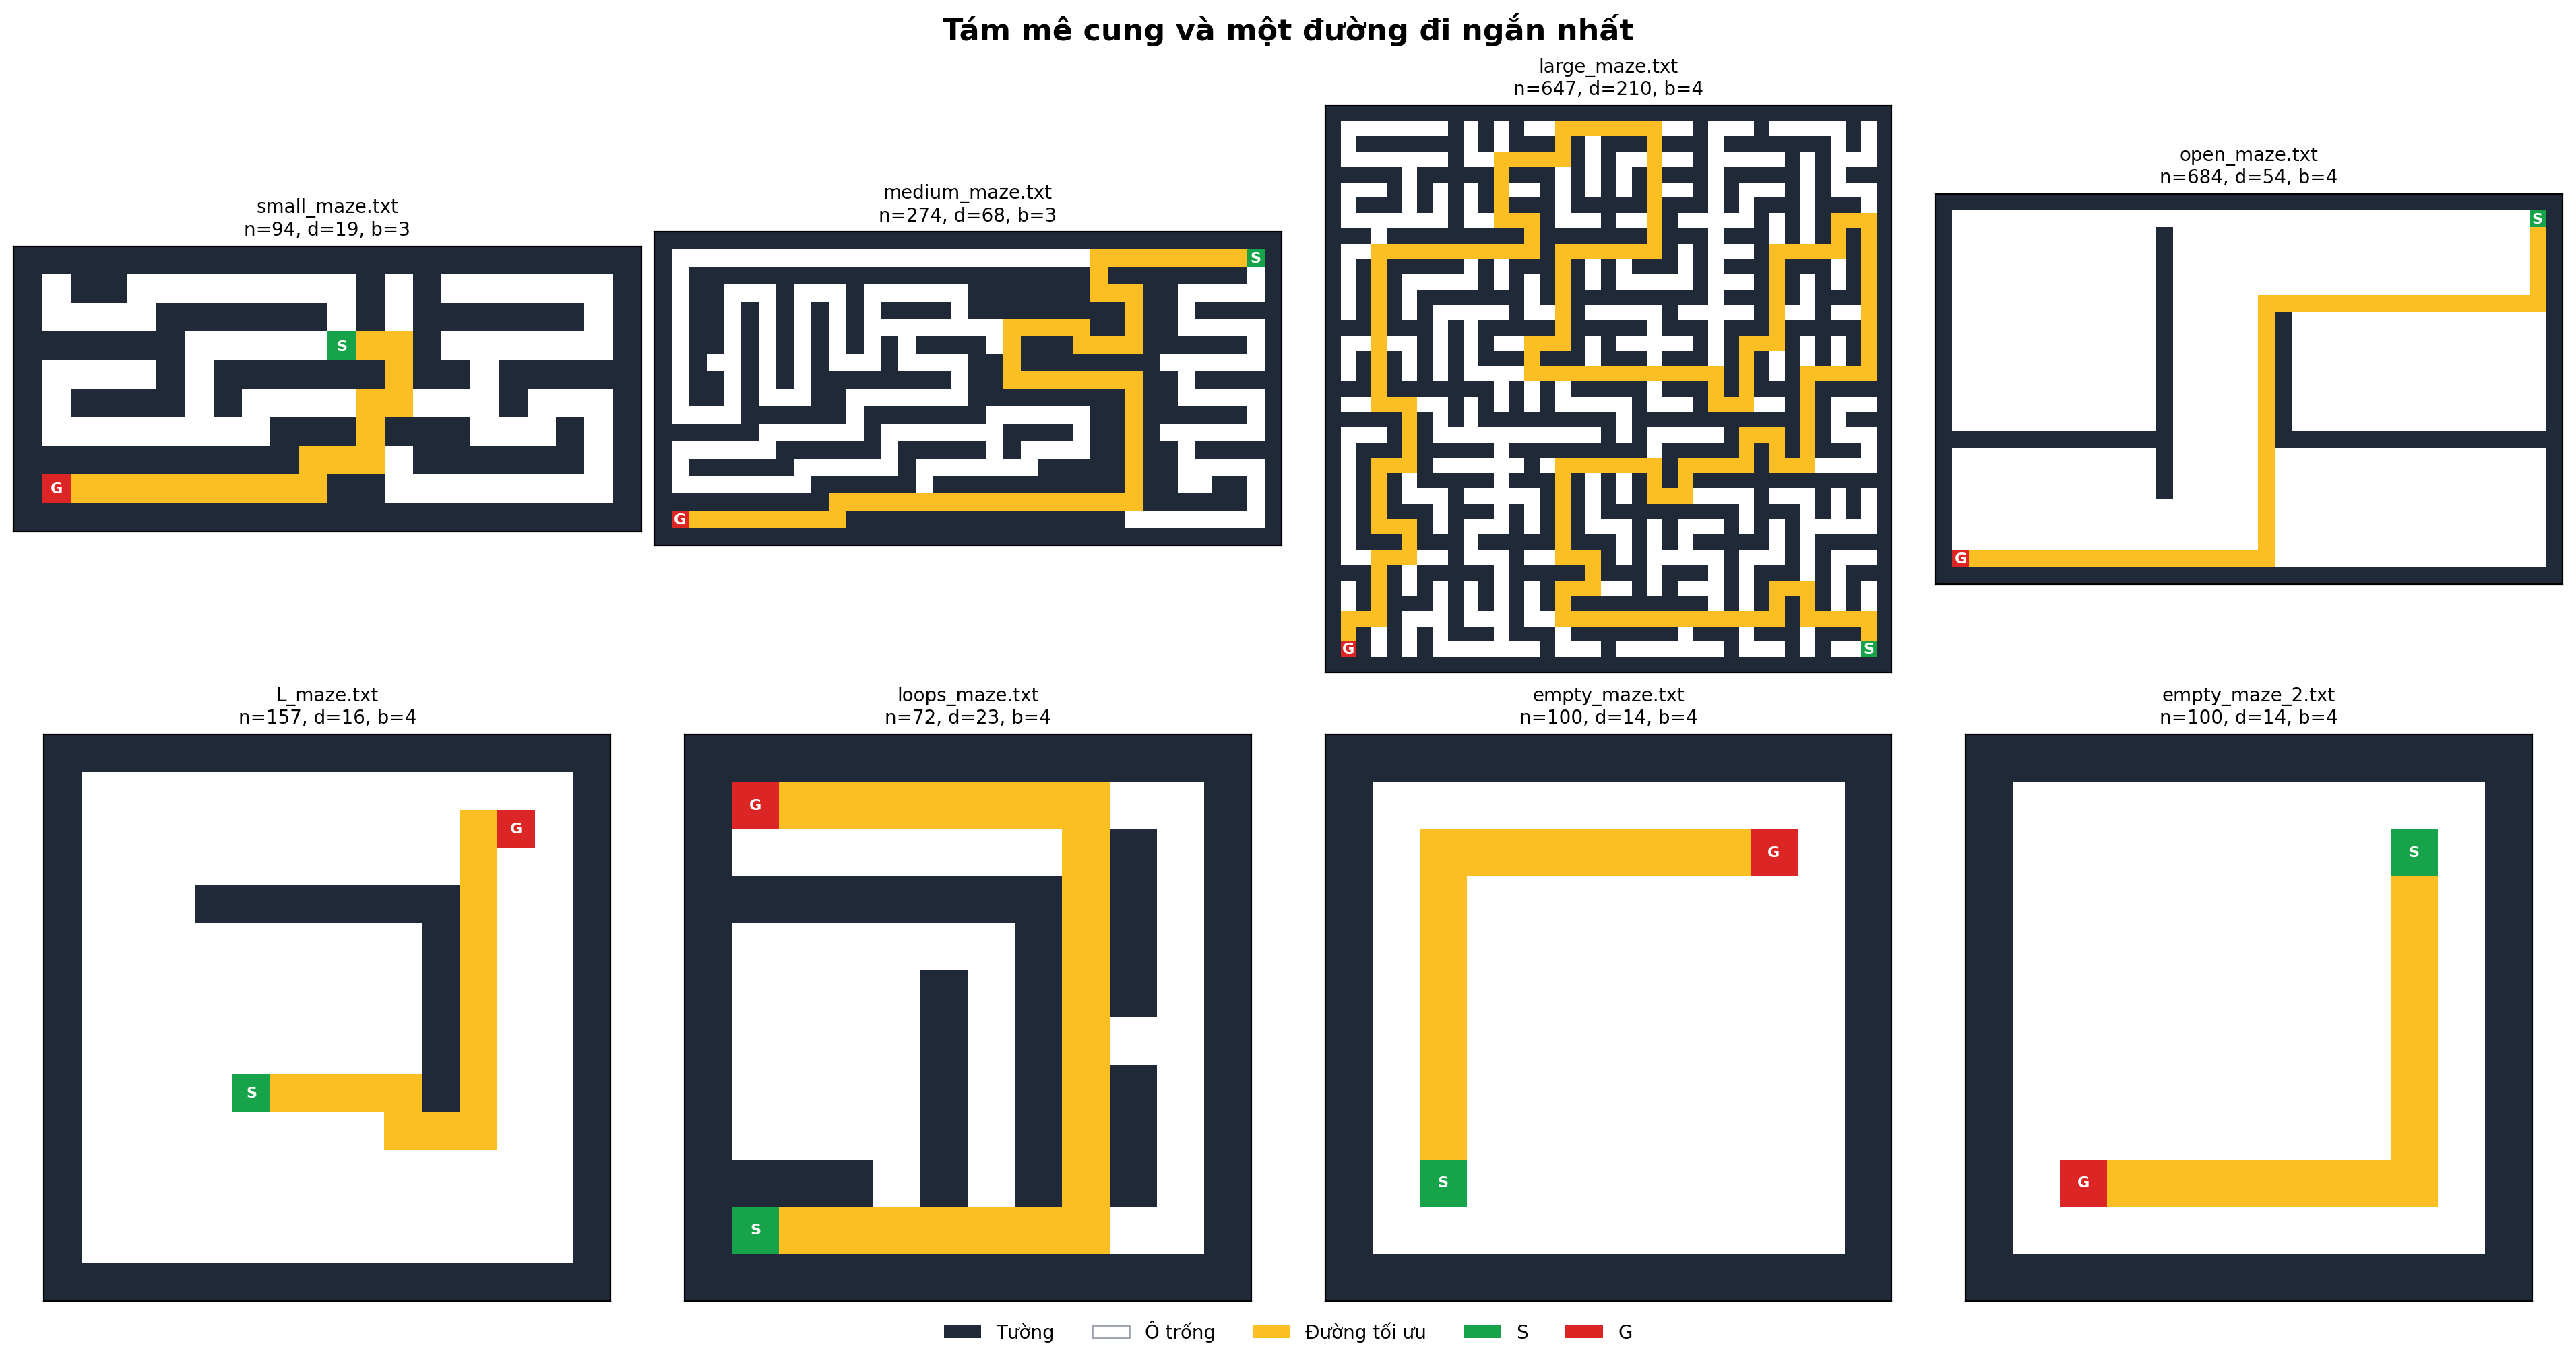

In [4]:
cmap = ListedColormap(['#ffffff', '#1f2937', '#fbbf24', '#16a34a', '#dc2626'])
fig, axes = plt.subplots(2, 4, figsize=(19, 10), constrained_layout=True)

for ax, item in zip(axes.flat, analyses):
    maze = item['maze']
    image = np.zeros(maze.shape, dtype=int)
    image[maze == 'X'] = 1
    if item['path'] is not None:
        for state in item['path'][1:-1]:
            image[state] = 2
    image[item['start']] = 3
    image[item['goal']] = 4

    ax.imshow(image, cmap=cmap, vmin=0, vmax=4, interpolation='nearest')
    ax.text(item['start'][1], item['start'][0], 'S', ha='center', va='center',
            color='white', fontsize=8, fontweight='bold')
    ax.text(item['goal'][1], item['goal'][0], 'G', ha='center', va='center',
            color='white', fontsize=8, fontweight='bold')
    ax.set_title(f"{item['filename']}\nn={item['reachable']}, d={item['d']}, b={item['b']}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

legend = [
    Patch(facecolor='#1f2937', label='Tường'),
    Patch(facecolor='#ffffff', edgecolor='#9ca3af', label='Ô trống'),
    Patch(facecolor='#fbbf24', label='Đường tối ưu'),
    Patch(facecolor='#16a34a', label='S'),
    Patch(facecolor='#dc2626', label='G'),
]
fig.legend(handles=legend, loc='outside lower center', ncol=5, frameon=False)
fig.suptitle('Tám mê cung và một đường đi ngắn nhất', fontsize=16, fontweight='bold')
plt.show()

## 5. So sánh trực quan các đại lượng

Hai biểu đồ tách riêng $n$ và độ sâu để tránh việc mê cung lớn che khuất các chênh lệch còn lại.

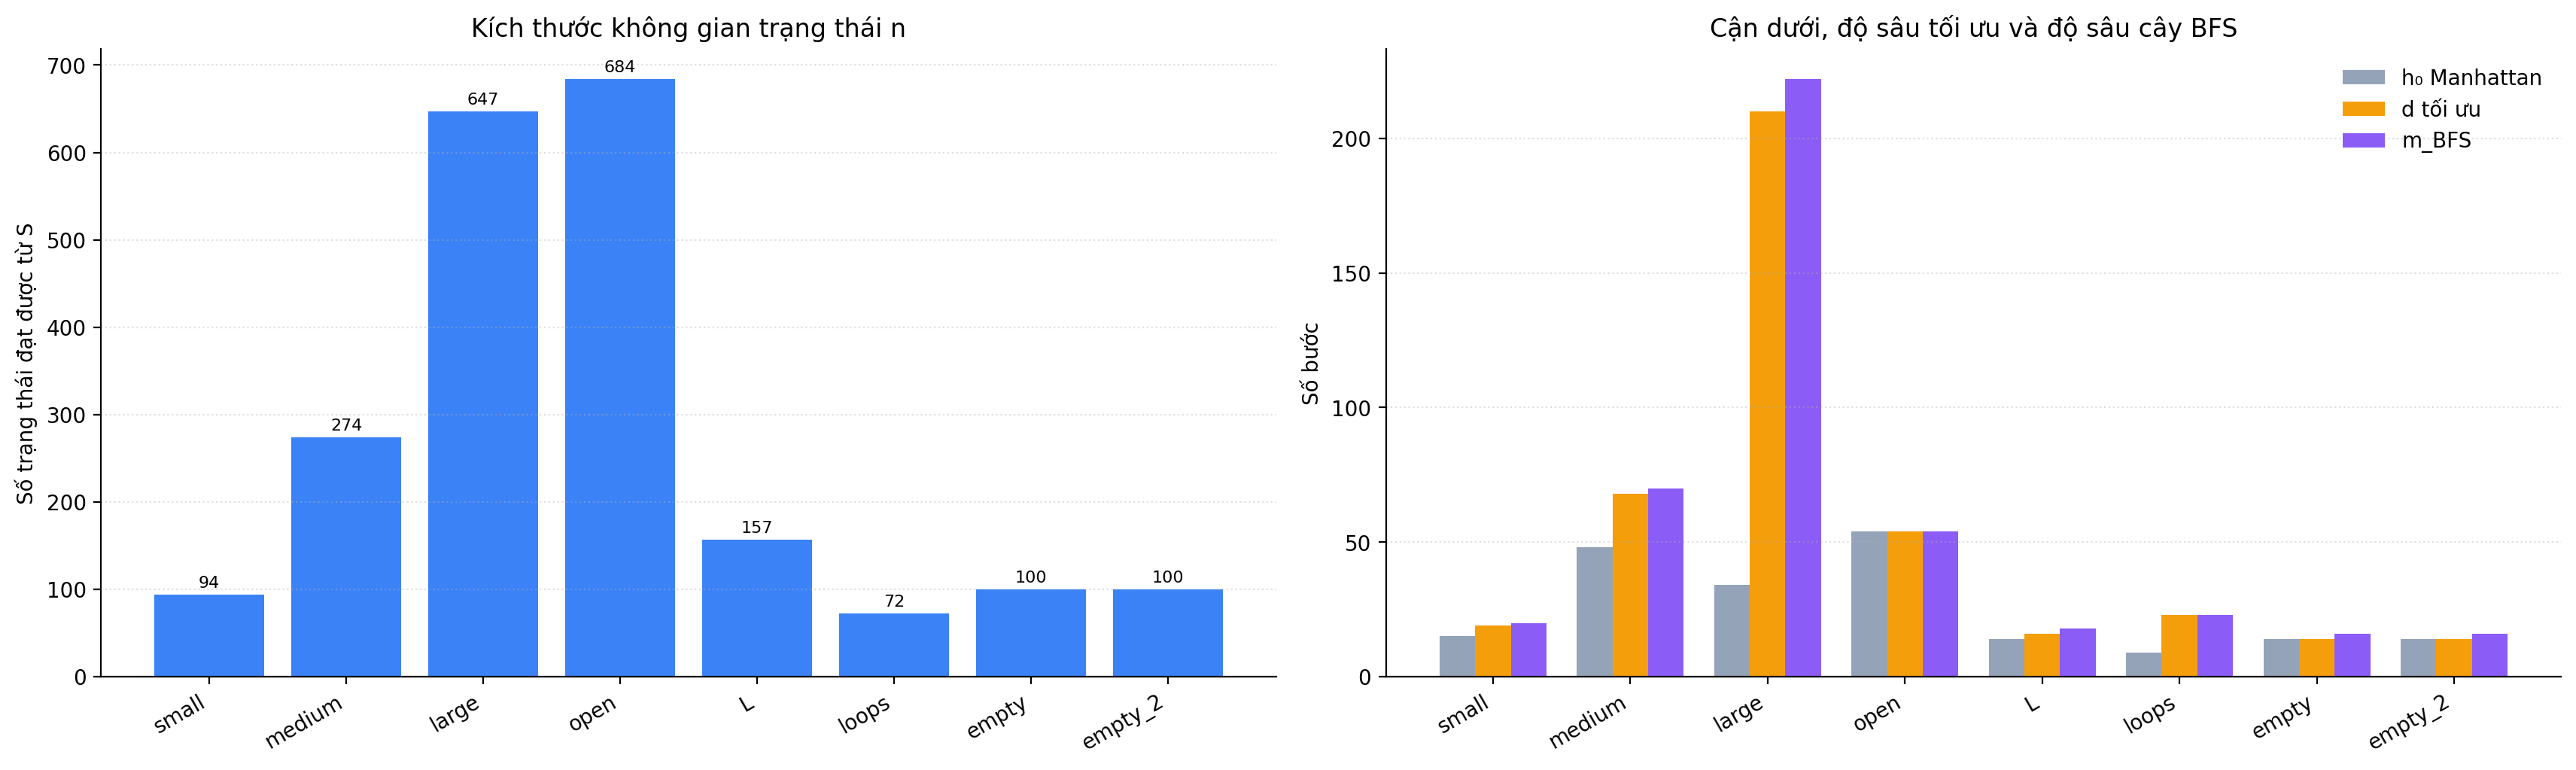

In [5]:
labels = [row['mê cung'] for row in rows]
x = np.arange(len(labels))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5), constrained_layout=True)

n_values = [item['reachable'] for item in analyses]
bars = ax1.bar(x, n_values, color='#3b82f6')
ax1.bar_label(bars, padding=2, fontsize=8)
ax1.set_title('Kích thước không gian trạng thái n')
ax1.set_ylabel('Số trạng thái đạt được từ S')

width = 0.26
h_values = [item['manhattan'] for item in analyses]
d_values = [item['d'] for item in analyses]
m_values = [item['m_bfs'] for item in analyses]
ax2.bar(x - width, h_values, width, label='h₀ Manhattan', color='#94a3b8')
ax2.bar(x, d_values, width, label='d tối ưu', color='#f59e0b')
ax2.bar(x + width, m_values, width, label='m_BFS', color='#8b5cf6')
ax2.set_title('Cận dưới, độ sâu tối ưu và độ sâu cây BFS')
ax2.set_ylabel('Số bước')
ax2.legend(frameon=False)

for ax in (ax1, ax2):
    ax.set_xticks(x, labels, rotation=30, ha='right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

## 6. Kiểm chứng tự động

Các kiểm tra dưới đây bảo đảm số liệu không chỉ được quan sát bằng mắt: đường bắt đầu tại `S`, kết thúc tại `G`, không xuyên tường, mỗi bước đi đúng một ô, số hành động bằng $d$, và các cận lý thuyết đều được thỏa mãn.

In [6]:
for item in analyses:
    maze, path = item['maze'], item['path']
    assert item['reachable'] == item['walkable'], f"{item['filename']}: có ô đi được bị cô lập"
    assert path is not None and path[0] == item['start'] and path[-1] == item['goal']
    assert len(path) - 1 == item['d'] == len(item['actions'])
    assert item['manhattan'] <= item['d'] <= item['m_simple_upper']
    assert item['m_bfs'] <= item['m_simple_upper'] and item['b'] <= 4
    for current, nxt in zip(path, path[1:]):
        assert abs(current[0] - nxt[0]) + abs(current[1] - nxt[1]) == 1
        assert maze[nxt] != 'X'

print('✓ Tất cả 8 mê cung và mọi đường đi đều vượt qua kiểm chứng.')

✓ Tất cả 8 mê cung và mọi đường đi đều vượt qua kiểm chứng.


## 7. Kết luận ngắn gọn

Mê cung được biểu diễn tự nhiên thành đồ thị không trọng số: mỗi ô đi được là một đỉnh, mỗi phép di chuyển hợp lệ là một cạnh. Do chi phí mỗi cạnh bằng 1, BFS là công cụ phù hợp để đo chính xác $d$ và dựng một đường tối ưu.

Với cài đặt graph search, thời gian BFS là $O(n+e)$ và bộ nhớ là $O(n)$; trên lưới bốn hướng $e\le2n$, nên cả hai đều là $O(n)$. Nếu phân tích theo cây tìm kiếm tổng quát, thường viết thời gian và bộ nhớ BFS là $O(b^{d+1})$. Kết quả thực nghiệm cũng cho thấy độ khó không chỉ phụ thuộc $n$: cấu trúc tường có thể làm $d$ lớn hơn rất nhiều so với khoảng cách thẳng Manhattan.